In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize

from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode

In [18]:
train_df = pd.read_csv("/kaggle/sign_mnist_train.csv")
test_df = pd.read_csv("/kaggle/sign_mnist_test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

num_classes = max(train_df["label"].max(), test_df["label"].max()) + 1
print("Number of classes:", num_classes)

Train shape: (27455, 785)
Test shape: (7172, 785)
Number of classes: 25


In [20]:
class SignLanguageSequenceDataset(Dataset):
    def __init__(self, df, augment=False, max_rotation=10):
        self.labels = df["label"].values.astype(np.int64)
        self.images = df.drop(columns=["label"]).values.astype(np.float32) / 255.0
        self.images = self.images.reshape(-1, 28, 28)
        self.augment = augment
        self.max_rotation = max_rotation

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        image = self.images[idx]  # shape: (28, 28)
        label = self.labels[idx]

        image_tensor = torch.tensor(image, dtype=torch.float32).unsqueeze(0)  # (1, 28, 28)

        if self.augment:
            angle = np.random.uniform(-self.max_rotation, self.max_rotation)
            image_tensor = TF.rotate(
                image_tensor,
                angle=angle,
                interpolation=InterpolationMode.BILINEAR
            )

        image_tensor = image_tensor.squeeze(0)  # back to (28, 28)

        x = image_tensor.float()      # LSTM input: (seq_len=28, input_size=28)
        y = torch.tensor(label, dtype=torch.long)

        return x, y

In [21]:
full_train_dataset_aug = SignLanguageSequenceDataset(train_df, augment=True, max_rotation=10)
full_train_dataset_noaug = SignLanguageSequenceDataset(train_df, augment=False)
test_dataset = SignLanguageSequenceDataset(test_df, augment=False)

In [22]:
full_train_dataset_aug = SignLanguageSequenceDataset(train_df, augment=True, max_rotation=10)
full_train_dataset_noaug = SignLanguageSequenceDataset(train_df, augment=False)
test_dataset = SignLanguageSequenceDataset(test_df, augment=False)

In [23]:
class SignLSTM(nn.Module):
    def __init__(self, input_size=28, hidden_size=128, num_layers=2, num_classes=25, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x shape: (batch, 28, 28)
        _, (hidden, _) = self.lstm(x)
        final_hidden = hidden[-1]   # final layer hidden state
        out = self.fc(final_hidden)
        return out

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for X, y in loader:
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X.size(0)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)

            outputs = model(X)
            loss = criterion(outputs, y)

            probs = torch.softmax(outputs, dim=1)
            preds = outputs.argmax(dim=1)

            running_loss += loss.item() * X.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds), np.array(all_probs)

Using device: cpu


In [26]:
k = 5
num_epochs = 15
batch_size = 128
learning_rate = 0.001

kf = KFold(n_splits=k, shuffle=True, random_state=42)

fold_results = []

for fold, (train_val_idx, holdout_idx) in enumerate(kf.split(train_df), start=1):
    print(f"\n========== Fold {fold}/{k} ==========")

    # Split fold's train_val portion again into train and validation
    train_idx, val_idx = train_test_split(
        train_val_idx,
        test_size=0.15,
        random_state=42,
        stratify=train_df.iloc[train_val_idx]["label"]
    )

    # Augmented training subset
    train_subset = Subset(full_train_dataset_aug, train_idx)

    # Non-augmented validation subset
    val_subset = Subset(full_train_dataset_noaug, val_idx)

    # Non-augmented fold holdout subset
    holdout_subset = Subset(full_train_dataset_noaug, holdout_idx)

    train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False)
    holdout_loader = DataLoader(holdout_subset, batch_size=batch_size, shuffle=False)

    model = SignLSTM(
        input_size=28,
        hidden_size=128,
        num_layers=2,
        num_classes=num_classes,
        dropout=0.3
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }

    best_val_acc = 0.0
    best_model_state = None

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
            f"Epoch {epoch+1:02d}/{num_epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        )

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict()

    # Load best model from this fold
    model.load_state_dict(best_model_state)

    holdout_loss, holdout_acc, _, _, _ = evaluate(model, holdout_loader, criterion, device)

    print(f"Best validation accuracy for fold {fold}: {best_val_acc:.4f}")
    print(f"Fold {fold} holdout accuracy: {holdout_acc:.4f}")

    fold_results.append({
        "fold": fold,
        "best_val_acc": best_val_acc,
        "holdout_acc": holdout_acc,
        "history": history
    })

print("\n========== K-Fold Summary ==========")
for res in fold_results:
    print(
        f"Fold {res['fold']}: "
        f"Best Val Acc = {res['best_val_acc']:.4f}, "
        f"Holdout Acc = {res['holdout_acc']:.4f}"
    )

mean_holdout_acc = np.mean([res["holdout_acc"] for res in fold_results])
print(f"\nMean holdout accuracy across {k} folds: {mean_holdout_acc:.4f}")


========== Fold 1/5 ==========
Epoch 01/15 | Train Loss: 2.7232 | Train Acc: 0.1666 | Val Loss: 2.0872 | Val Acc: 0.3284
Epoch 02/15 | Train Loss: 1.6208 | Train Acc: 0.4786 | Val Loss: 1.1856 | Val Acc: 0.6209
Epoch 03/15 | Train Loss: 1.0458 | Train Acc: 0.6534 | Val Loss: 0.7749 | Val Acc: 0.7524
Epoch 04/15 | Train Loss: 0.7088 | Train Acc: 0.7717 | Val Loss: 0.5876 | Val Acc: 0.8027
Epoch 05/15 | Train Loss: 0.4804 | Train Acc: 0.8548 | Val Loss: 0.3008 | Val Acc: 0.9208
Epoch 06/15 | Train Loss: 0.3164 | Train Acc: 0.9096 | Val Loss: 0.1958 | Val Acc: 0.9536
Epoch 07/15 | Train Loss: 0.2362 | Train Acc: 0.9328 | Val Loss: 0.1376 | Val Acc: 0.9684
Epoch 08/15 | Train Loss: 0.1671 | Train Acc: 0.9562 | Val Loss: 0.0983 | Val Acc: 0.9809
Epoch 09/15 | Train Loss: 0.1284 | Train Acc: 0.9679 | Val Loss: 0.0831 | Val Acc: 0.9821
Epoch 10/15 | Train Loss: 0.1079 | Train Acc: 0.9732 | Val Loss: 0.0372 | Val Acc: 0.9973
Epoch 11/15 | Train Loss: 0.0810 | Train Acc: 0.9809 | Val Loss: 0.0

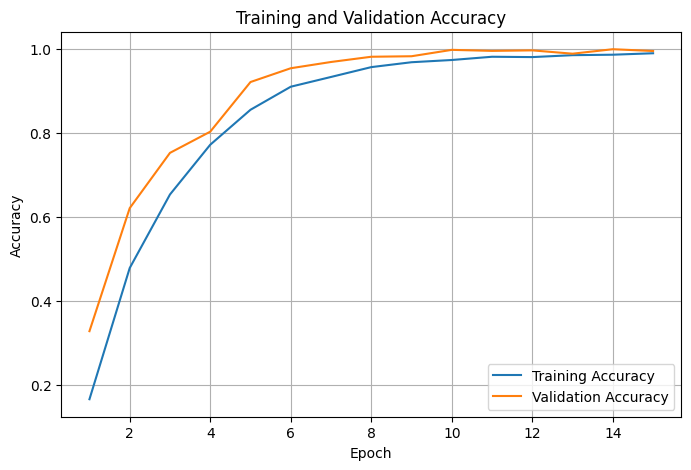

In [27]:
# Example: plot results from fold 1
chosen_fold = fold_results[0]
history = chosen_fold["history"]

epochs = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_acc"], label="Training Accuracy")
plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [28]:
train_indices, val_indices = train_test_split(
    np.arange(len(train_df)),
    test_size=0.15,
    random_state=42,
    stratify=train_df["label"]
)

final_train_subset = Subset(full_train_dataset_aug, train_indices)
final_val_subset = Subset(full_train_dataset_noaug, val_indices)

final_train_loader = DataLoader(final_train_subset, batch_size=128, shuffle=True)
final_val_loader = DataLoader(final_val_subset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

final_model = SignLSTM(
    input_size=28,
    hidden_size=128,
    num_layers=2,
    num_classes=num_classes,
    dropout=0.3
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(final_model.parameters(), lr=0.001)

final_history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_val_acc = 0.0
best_model_state = None
num_epochs = 15

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(final_model, final_train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _, _ = evaluate(final_model, final_val_loader, criterion, device)

    final_history["train_loss"].append(train_loss)
    final_history["train_acc"].append(train_acc)
    final_history["val_loss"].append(val_loss)
    final_history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch+1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = final_model.state_dict()

final_model.load_state_dict(best_model_state)
print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch 01/15 | Train Loss: 2.5369 | Train Acc: 0.2257 | Val Loss: 1.6946 | Val Acc: 0.4499
Epoch 02/15 | Train Loss: 1.3283 | Train Acc: 0.5668 | Val Loss: 1.0400 | Val Acc: 0.6657
Epoch 03/15 | Train Loss: 0.7937 | Train Acc: 0.7440 | Val Loss: 0.5933 | Val Acc: 0.8148
Epoch 04/15 | Train Loss: 0.4691 | Train Acc: 0.8598 | Val Loss: 0.2925 | Val Acc: 0.9274
Epoch 05/15 | Train Loss: 0.3092 | Train Acc: 0.9088 | Val Loss: 0.1821 | Val Acc: 0.9587
Epoch 06/15 | Train Loss: 0.1909 | Train Acc: 0.9487 | Val Loss: 0.1134 | Val Acc: 0.9733
Epoch 07/15 | Train Loss: 0.1325 | Train Acc: 0.9651 | Val Loss: 0.1163 | Val Acc: 0.9684
Epoch 08/15 | Train Loss: 0.0995 | Train Acc: 0.9740 | Val Loss: 0.0437 | Val Acc: 0.9915
Epoch 09/15 | Train Loss: 0.0966 | Train Acc: 0.9745 | Val Loss: 0.0265 | Val Acc: 0.9973
Epoch 10/15 | Train Loss: 0.0779 | Train Acc: 0.9791 | Val Loss: 0.0267 | Val Acc: 0.9966
Epoch 11/15 | Train Loss: 0.0335 | Train Acc: 0.9934 | Val Loss: 0.0246 | Val Acc: 0.9947
Epoch 12/1

In [29]:
def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)

            outputs = model(X)
            loss = criterion(outputs, y)

            # Convert logits → probabilities
            probs = torch.softmax(outputs, dim=1)

            preds = outputs.argmax(dim=1)

            running_loss += loss.item() * X.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, np.array(all_labels), np.array(all_preds), np.array(all_probs)

In [30]:
test_loss, test_acc, y_true, y_pred, y_prob = evaluate(final_model, test_loader, criterion, device)

print("\nFinal Test Accuracy:", round(test_acc, 4))
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))
print("\nConfusion Matrix:\n")
print(confusion_matrix(y_true, y_pred))


Final Test Accuracy: 0.8935

Classification Report:

              precision    recall  f1-score   support

           0       0.87      1.00      0.93       331
           1       1.00      1.00      1.00       432
           2       0.86      0.99      0.92       310
           3       0.91      1.00      0.95       245
           4       0.96      0.93      0.95       498
           5       0.95      1.00      0.97       247
           6       0.84      0.88      0.86       348
           7       1.00      0.93      0.97       436
           8       0.92      0.90      0.91       288
          10       0.96      0.85      0.90       331
          11       0.89      1.00      0.94       209
          12       0.83      0.86      0.85       394
          13       0.88      0.59      0.71       291
          14       0.99      0.71      0.83       246
          15       1.00      1.00      1.00       347
          16       0.91      1.00      0.95       164
          17       0.55    

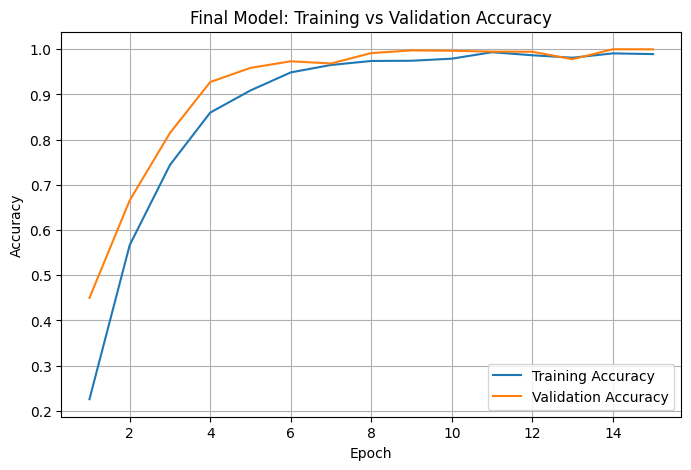

In [31]:
epochs = range(1, len(final_history["train_acc"]) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, final_history["train_acc"], label="Training Accuracy")
plt.plot(epochs, final_history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Final Model: Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

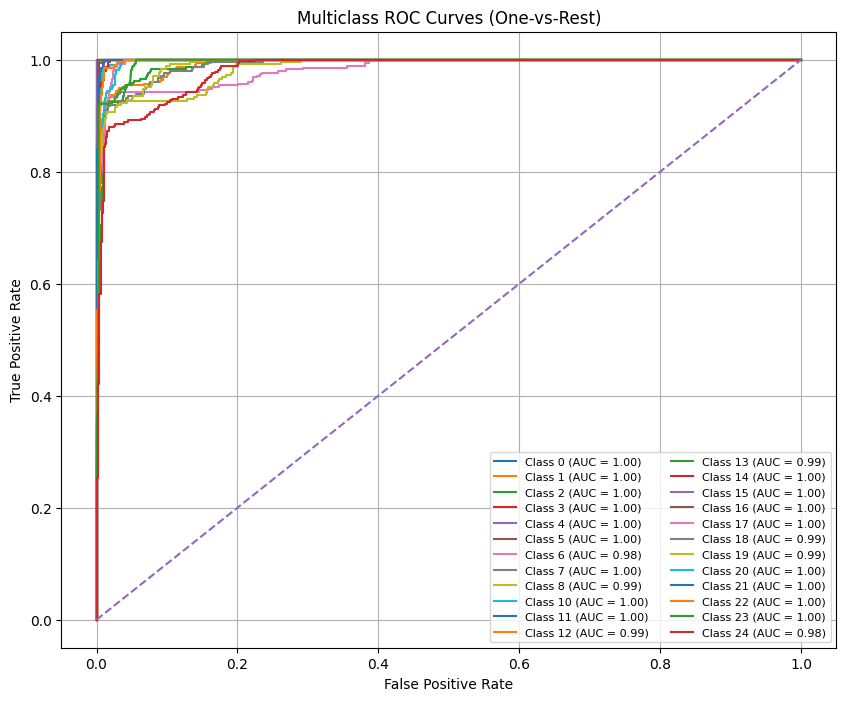

In [32]:
# Binarize the true labels for multiclass ROC
class_labels = np.unique(np.concatenate([y_true, y_pred]))
y_true_bin = label_binarize(y_true, classes=class_labels)

# If labels are not continuous from 0..num_classes-1, align probabilities carefully
# In this dataset, the labels usually skip one class index, so we select only the relevant columns
y_prob_aligned = y_prob[:, class_labels]

fpr = {}
tpr = {}
roc_auc = {}

for i, cls in enumerate(class_labels):
    fpr[cls], tpr[cls], _ = roc_curve(y_true_bin[:, i], y_prob_aligned[:, i])
    roc_auc[cls] = auc(fpr[cls], tpr[cls])

plt.figure(figsize=(10, 8))
for cls in class_labels:
    plt.plot(fpr[cls], tpr[cls], label=f"Class {cls} (AUC = {roc_auc[cls]:.2f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves (One-vs-Rest)")
plt.legend(loc="lower right", fontsize=8, ncol=2)
plt.grid(True)
plt.show()

In [33]:
macro_auc = np.mean(list(roc_auc.values()))
print("Macro-average ROC AUC:", round(macro_auc, 4))

Macro-average ROC AUC: 0.9958
